<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/An%C3%A1lisis_Exploratorio_de_Datos_(EDA)_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Configuración para mejor visualización
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')

In [7]:
# Crear dataset sintético con problemas de calidad de datos
np.random.seed(42)
n_samples = 1000

data = {
    'edad': np.random.normal(50, 15, n_samples),
    'genero': np.random.choice(['M', 'F', 'Unknown', ' '], n_samples, p=[0.48, 0.48, 0.02, 0.02]),
    'imc': np.random.normal(28, 6, n_samples),
    'presion_arterial': np.random.normal(80, 12, n_samples),
    'colesterol_total': np.random.normal(200, 40, n_samples),
    'hdl_colesterol': np.random.normal(50, 15, n_samples),
    'ldl_colesterol': np.random.normal(120, 35, n_samples),
    'trigliceridos': np.random.normal(150, 80, n_samples),
    'glucosa_ayunas': np.random.normal(110, 30, n_samples),
    'hemoglobina_glicada': np.random.normal(6.5, 1.5, n_samples),
    'diabetes': np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
}

df = pd.DataFrame(data)
display(df)

,edad,genero,imc,presion_arterial,colesterol_total,hdl_colesterol,ldl_colesterol,trigliceridos,glucosa_ayunas,hemoglobina_glicada,diabetes
0,57.450712,M,26.144746,70.760047,212.654333,60.964385,116.255999,228.114510,113.185488,7.444041,1
1,47.926035,M,23.487062,64.446600,164.590053,40.240103,187.978596,59.428069,90.865739,6.051396,0
2,59.715328,F,29.915047,74.526550,207.242510,18.645457,58.847242,62.086700,108.264902,7.518941,0
3,72.845448,F,36.042703,82.177119,252.131121,47.446126,123.311737,204.994140,143.833641,5.434795,0
4,46.487699,M,16.748965,87.140354,223.446632,46.015932,63.105959,142.916463,113.419120,3.327960,1
...,...,...,...,...,...,...,...,...,...,...,...
995,45.783496,M,24.101409,76.079645,211.662547,39.732624,120.307595,231.217671,138.678075,8.107214,0
996,76.965298,M,20.780795,67.489068,132.373135,56.859864,122.025242,158.638714,145.506473,4.835375,0
997,59.612643,F,21.747734,65.933195,160.860018,81.473322,110.704258,358.548733,75.060100,6.984871,0
998,41.432315,M,25.076782,85.572438,310.208710,47.928765,143.955767,165.472509,73.882591,4.178645,0


In [8]:
#INTRODUCIR PROBLEMAS DE CALIDAD AL DATASET
# 1. Introducir valores nulos aleatorios
for col in df.columns:
    if col != 'diabetes':
        null_indices = np.random.choice(df.index, size=int(len(df)*0.1), replace=False)
        df.loc[null_indices, col] = np.nan

In [9]:
# 2. Introducir outliers extremos
outlier_indices = np.random.choice(df.index, size=int(len(df)*0.05), replace=False)
df.loc[outlier_indices, 'imc'] = np.random.uniform(60, 100, len(outlier_indices))
df.loc[outlier_indices, 'glucosa_ayunas'] = np.random.uniform(300, 500, len(outlier_indices))

In [10]:
# 3. Introducir valores inconsistentes
inconsistent_indices = np.random.choice(df.index, size=int(len(df)*0.03), replace=False)
df.loc[inconsistent_indices, 'edad'] = np.random.uniform(150, 200, len(inconsistent_indices))

In [11]:
# 4. Introducir duplicados
df_duplicates = df.sample(n=50, random_state=42)
df = pd.concat([df, df_duplicates], ignore_index=True)

In [12]:
# 5. Introducir errores de formato
format_indices = np.random.choice(df.index, size=int(len(df)*0.02), replace=False)
df.loc[format_indices, 'genero'] = 'XYZ'
df.loc[format_indices, 'presion_arterial'] = 'invalid'

In [13]:
# 6. Introducir inconsistencias lógicas
logical_indices = np.random.choice(df.index, size=int(len(df)*0.04), replace=False)
df.loc[logical_indices, 'hdl_colesterol'] = df.loc[logical_indices, 'ldl_colesterol'] * 2

In [14]:
display(df)

,edad,genero,imc,presion_arterial,colesterol_total,hdl_colesterol,ldl_colesterol,trigliceridos,glucosa_ayunas,hemoglobina_glicada,diabetes
0,57.450712,M,26.144746,70.760047,212.654333,60.964385,116.255999,228.114510,113.185488,7.444041,1
1,47.926035,M,23.487062,64.4466,164.590053,40.240103,187.978596,59.428069,90.865739,6.051396,0
2,59.715328,F,88.121145,74.52655,207.242510,18.645457,NaN,62.086700,304.328138,7.518941,0
3,72.845448,F,36.042703,82.177119,252.131121,47.446126,123.311737,204.994140,143.833641,5.434795,0
4,46.487699,M,16.748965,NaN,223.446632,46.015932,63.105959,142.916463,113.419120,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
1045,40.996747,F,27.380669,73.648015,212.740840,29.884029,203.578870,159.369937,139.870813,5.317886,1
1046,67.925699,F,23.089428,62.769086,175.665969,51.305247,157.538963,176.617546,106.644587,4.929617,0
1047,36.167520,M,22.454601,NaN,142.693148,27.312066,70.221962,175.147095,121.110208,9.119736,0
1048,49.166785,F,35.927824,68.14552,220.796086,33.900080,108.526774,60.338588,95.608433,6.771307,0


In [15]:
# ANÁLISIS EXPLORATORIO INICIAL
#1. Información general
print("\n1. INFORMACIÓN GENERAL:")
display(df.info())


1. INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   edad                 943 non-null    float64
 1   genero               947 non-null    object 
 2   imc                  951 non-null    float64
 3   presion_arterial     947 non-null    object 
 4   colesterol_total     945 non-null    float64
 5   hdl_colesterol       942 non-null    float64
 6   ldl_colesterol       944 non-null    float64
 7   trigliceridos        947 non-null    float64
 8   glucosa_ayunas       948 non-null    float64
 9   hemoglobina_glicada  946 non-null    float64
 10  diabetes             1050 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 90.4+ KB


None

In [16]:
#2. Visualizar el Dataset
print("\n2. PRIMERAS 10 FILAS:")
display(df.head(10))


2. PRIMERAS 10 FILAS:


,edad,genero,imc,presion_arterial,colesterol_total,hdl_colesterol,ldl_colesterol,trigliceridos,glucosa_ayunas,hemoglobina_glicada,diabetes
0,57.450712,M,26.144746,70.760047,212.654333,60.964385,116.255999,228.114510,113.185488,7.444041,1
1,47.926035,M,23.487062,64.4466,164.590053,40.240103,187.978596,59.428069,90.865739,6.051396,0
2,59.715328,F,88.121145,74.52655,207.242510,18.645457,NaN,62.086700,304.328138,7.518941,0
3,72.845448,F,36.042703,82.177119,252.131121,47.446126,123.311737,204.994140,143.833641,5.434795,0
4,46.487699,M,16.748965,NaN,223.446632,46.015932,63.105959,142.916463,113.419120,NaN,1
5,46.487946,F,28.690156,73.310923,183.503447,44.001826,NaN,113.688687,86.196208,5.864148,0
6,NaN,M,27.039203,75.044026,NaN,48.280387,130.411172,221.204619,82.247461,6.594848,0
7,61.511521,F,32.028040,68.87962,190.373393,53.964024,124.882423,101.419087,96.493943,6.086240,0
8,42.957884,NaN,29.279180,79.62273,200.315207,47.748246,110.030707,133.983900,112.215903,4.762095,1
9,150.015354,F,23.488184,69.818856,186.975558,31.039907,116.283207,261.938236,145.807596,3.776527,1


In [17]:
#3. Estadísticas Descriptivas
print("\n3. ESTADÍSTICAS DESCRIPTIVAS:")
display(df.describe())


3. ESTADÍSTICAS DESCRIPTIVAS:


,edad,imc,colesterol_total,hdl_colesterol,ldl_colesterol,trigliceridos,glucosa_ayunas,hemoglobina_glicada,diabetes
count,943.000000,951.000000,945.000000,942.000000,944.000000,947.000000,948.000000,946.000000,1050.000000
mean,54.416588,30.909242,197.892435,56.618090,118.841832,150.551561,127.374443,6.450595,0.275238
std,26.269347,13.546476,39.343247,41.229506,36.449098,85.030383,74.101122,1.418227,0.446847
min,1.380990,9.882927,72.931847,7.504546,18.517014,-138.086808,-5.099666,0.616400,0.000000
25%,41.002929,24.249932,172.548835,40.228681,93.330945,90.795077,92.564820,5.564523,0.000000
50%,51.028445,28.305326,199.205055,49.738242,118.077815,149.591469,114.120679,6.463632,0.000000
75%,60.736571,32.703984,224.755452,60.590899,144.225819,209.240713,137.179551,7.404273,1.000000
max,196.373064,99.872858,326.082269,387.370820,228.440480,432.324415,497.814795,10.652560,1.000000


In [18]:
# 4. Conteo total de nulos por columna
print("\n=== Conteo de valores nulos por columna ===")
display(df.isnull().sum())


=== Conteo de valores nulos por columna ===


,0
edad,107
genero,103
imc,99
presion_arterial,103
colesterol_total,105
hdl_colesterol,108
ldl_colesterol,106
trigliceridos,103
glucosa_ayunas,102
hemoglobina_glicada,104


In [29]:
# Análisis de duplicados
print(f"DUPLICADOS: {df.duplicated().sum()} filas duplicadas")

DUPLICADOS: 47 filas duplicadas


In [30]:
# Análisis de tipos de datos problemáticos
print("TIPOS DE DATOS PROBLEMÁTICOS:")
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].unique()
        print(f"{col}: {unique_vals}")


TIPOS DE DATOS PROBLEMÁTICOS:
genero: ['M' 'F' nan 'XYZ' 'Unknown' ' ']
presion_arterial: [70.76004720563051 64.44660002900127 74.52655007030974 82.17711944136765
 nan 73.31092336270015 75.0440261342788 68.87962029383228
 79.62272995550268 69.81885638971022 86.8775337588944 58.56960209679067
 75.68444393057045 83.61328807030091 'invalid' 112.31640396776595
 84.19760029481489 67.95134483789587 58.68504399840258 79.03280300843888
 70.0033273159909 90.98468330672193 73.40551670485358 78.59880901045705
 72.37330590314716 100.86621622223998 76.14508680658506 101.99068452175042
 89.7698211454192 85.78480072802463 84.42479776781023 84.72556757859502
 56.867929047852684 76.65339927019092 90.14189565421185 79.41323379831073
 63.137721838357095 79.37114659307036 100.44926619506589 94.96270058641663
 79.25595188760762 75.60191575558338 59.553540958079374 68.90640814244534
 98.75466522209837 76.71208301804835 77.07939224749978 76.40194164470144
 102.84963907487608 99.51150698434476 106.62536280137

In [31]:
# Detección de outliers usando IQR
print("DETECCIÓN DE OUTLIERS (Método IQR):")
numeric_cols = df.select_dtypes(include=[np.number]).columns

outliers_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_pct = (len(outliers) / len(df)) * 100
    outliers_info[col] = {
        'count': len(outliers),
        'percentage': outliers_pct,
        'min': df[col].min(),
        'max': df[col].max()
    }

    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({outliers_pct:.2f}%) - Rango: [{df[col].min():.2f}, {df[col].max():.2f}]")

DETECCIÓN DE OUTLIERS (Método IQR):
edad: 36 outliers (3.43%) - Rango: [1.38, 196.37]
imc: 59 outliers (5.62%) - Rango: [9.88, 99.87]
colesterol_total: 10 outliers (0.95%) - Rango: [72.93, 326.08]
hdl_colesterol: 41 outliers (3.90%) - Rango: [7.50, 387.37]
ldl_colesterol: 3 outliers (0.29%) - Rango: [18.52, 228.44]
trigliceridos: 5 outliers (0.48%) - Rango: [-138.09, 432.32]
glucosa_ayunas: 60 outliers (5.71%) - Rango: [-5.10, 497.81]
hemoglobina_glicada: 9 outliers (0.86%) - Rango: [0.62, 10.65]


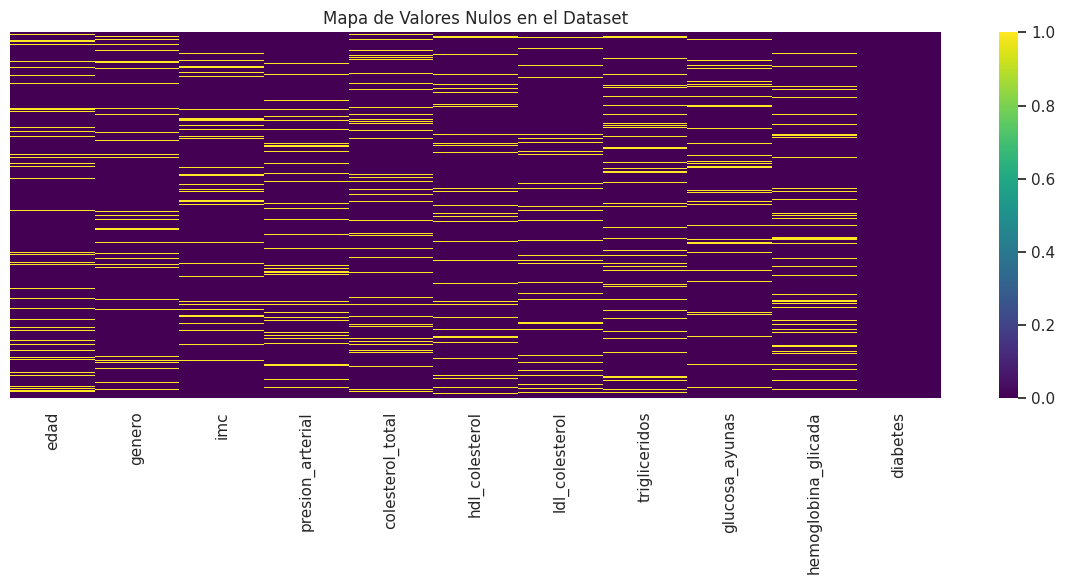

In [32]:
#Heatmap de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos en el Dataset')
plt.tight_layout()
plt.show()

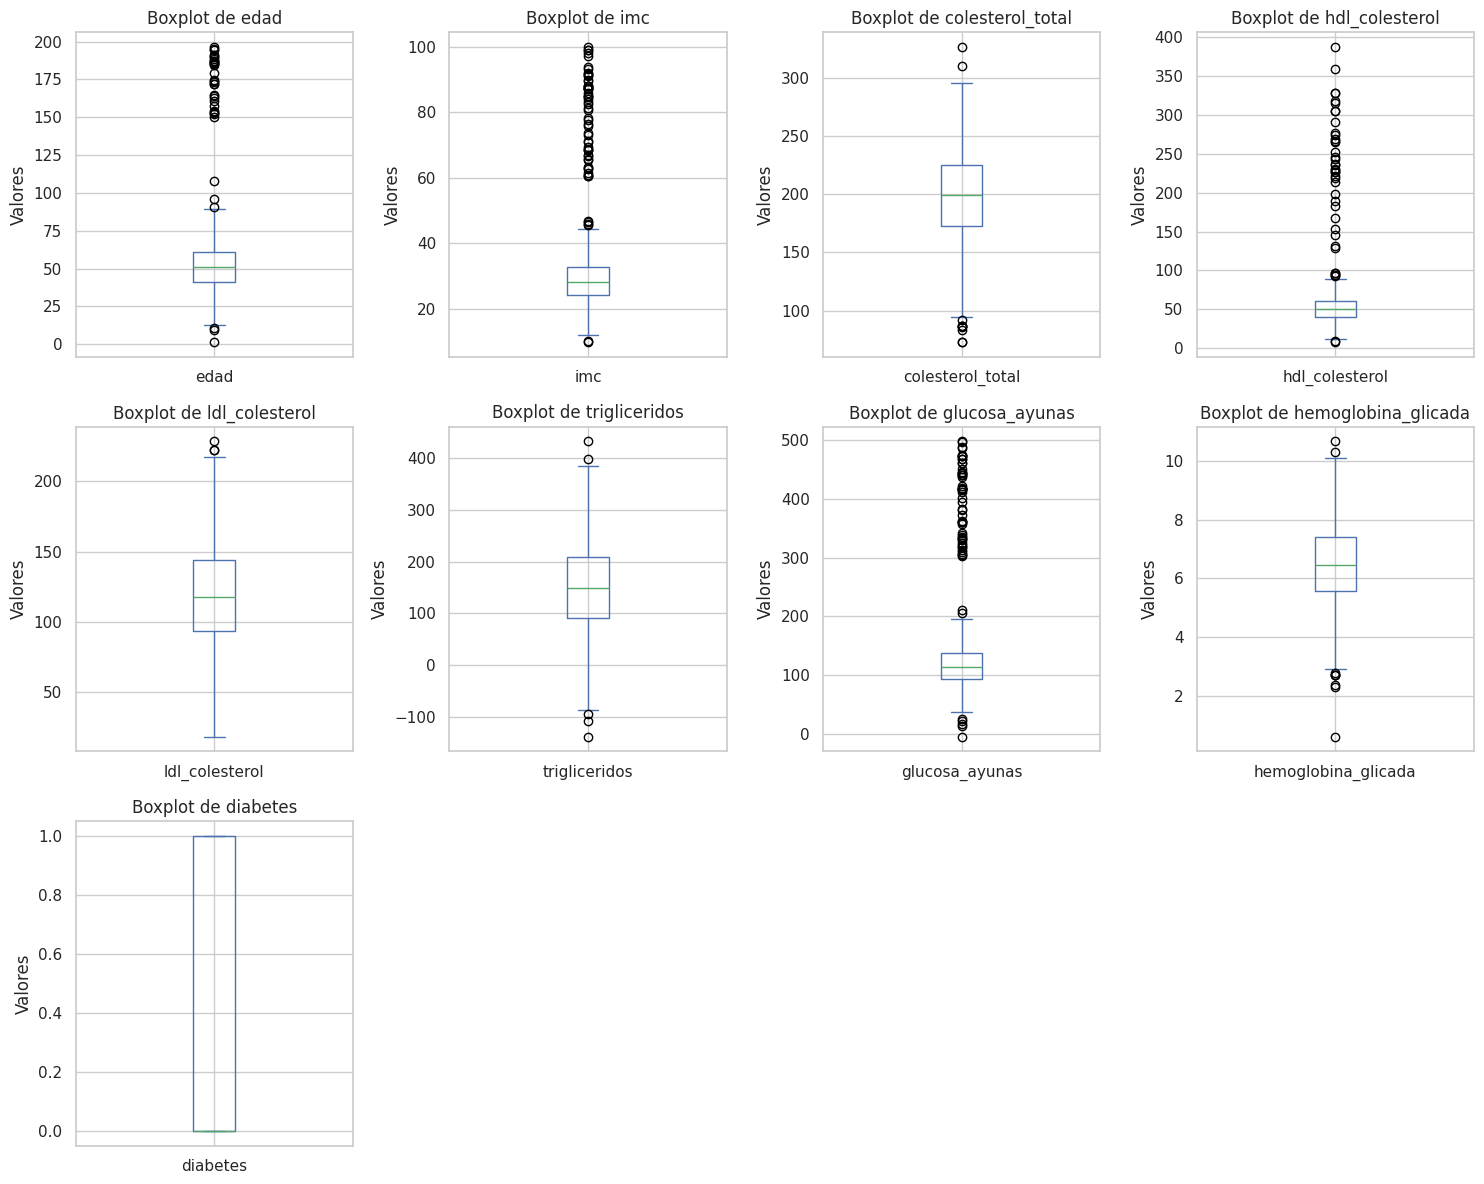

In [24]:
# 2. Boxplots para detectar outliers
numeric_cols_clean = [col for col in numeric_cols if df[col].notna().sum() > 0]
n_cols = min(4, len(numeric_cols_clean))
n_rows = (len(numeric_cols_clean) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(numeric_cols_clean[:len(axes)]):
    if i < len(axes):
        df[col].dropna().plot(kind='box', ax=axes[i], title=f'Boxplot de {col}')
        axes[i].set_ylabel('Valores')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

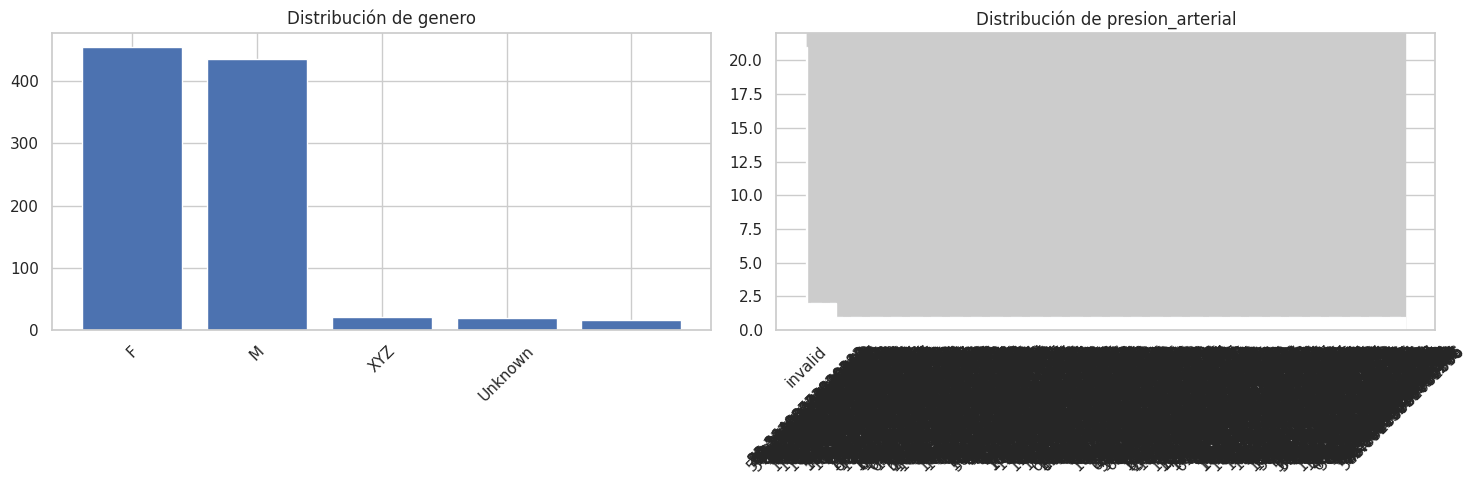

In [25]:
# Distribución de variables categóricas problemáticas
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 5))
    if len(categorical_cols) == 1:
        axes = [axes]

    for i, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        axes[i].bar(value_counts.index.astype(str), value_counts.values)
        axes[i].set_title(f'Distribución de {col}')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


=== CREANDO DATASET DE DIABETES CON PROBLEMAS DE CALIDAD ===
Introduciendo problemas de calidad de datos...
Dataset sucio creado exitosamente!
Dimensiones: (1050, 11)

ANÁLISIS EXPLORATORIO INICIAL

1. INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   edad                 943 non-null    float64
 1   genero               947 non-null    object 
 2   imc                  951 non-null    float64
 3   presion_arterial     947 non-null    object 
 4   colesterol_total     945 non-null    float64
 5   hdl_colesterol       942 non-null    float64
 6   ldl_colesterol       944 non-null    float64
 7   trigliceridos        947 non-null    float64
 8   glucosa_ayunas       948 non-null    float64
 9   hemoglobina_glicada  946 non-null    float64
 10  diabetes             1050 non-null   int64  
dtypes: float64(8), 

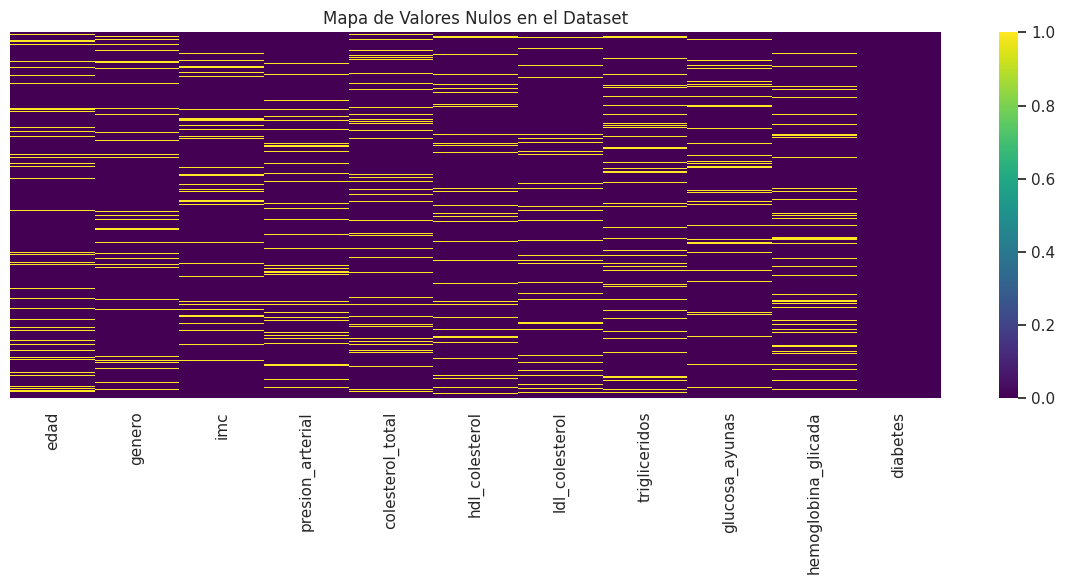

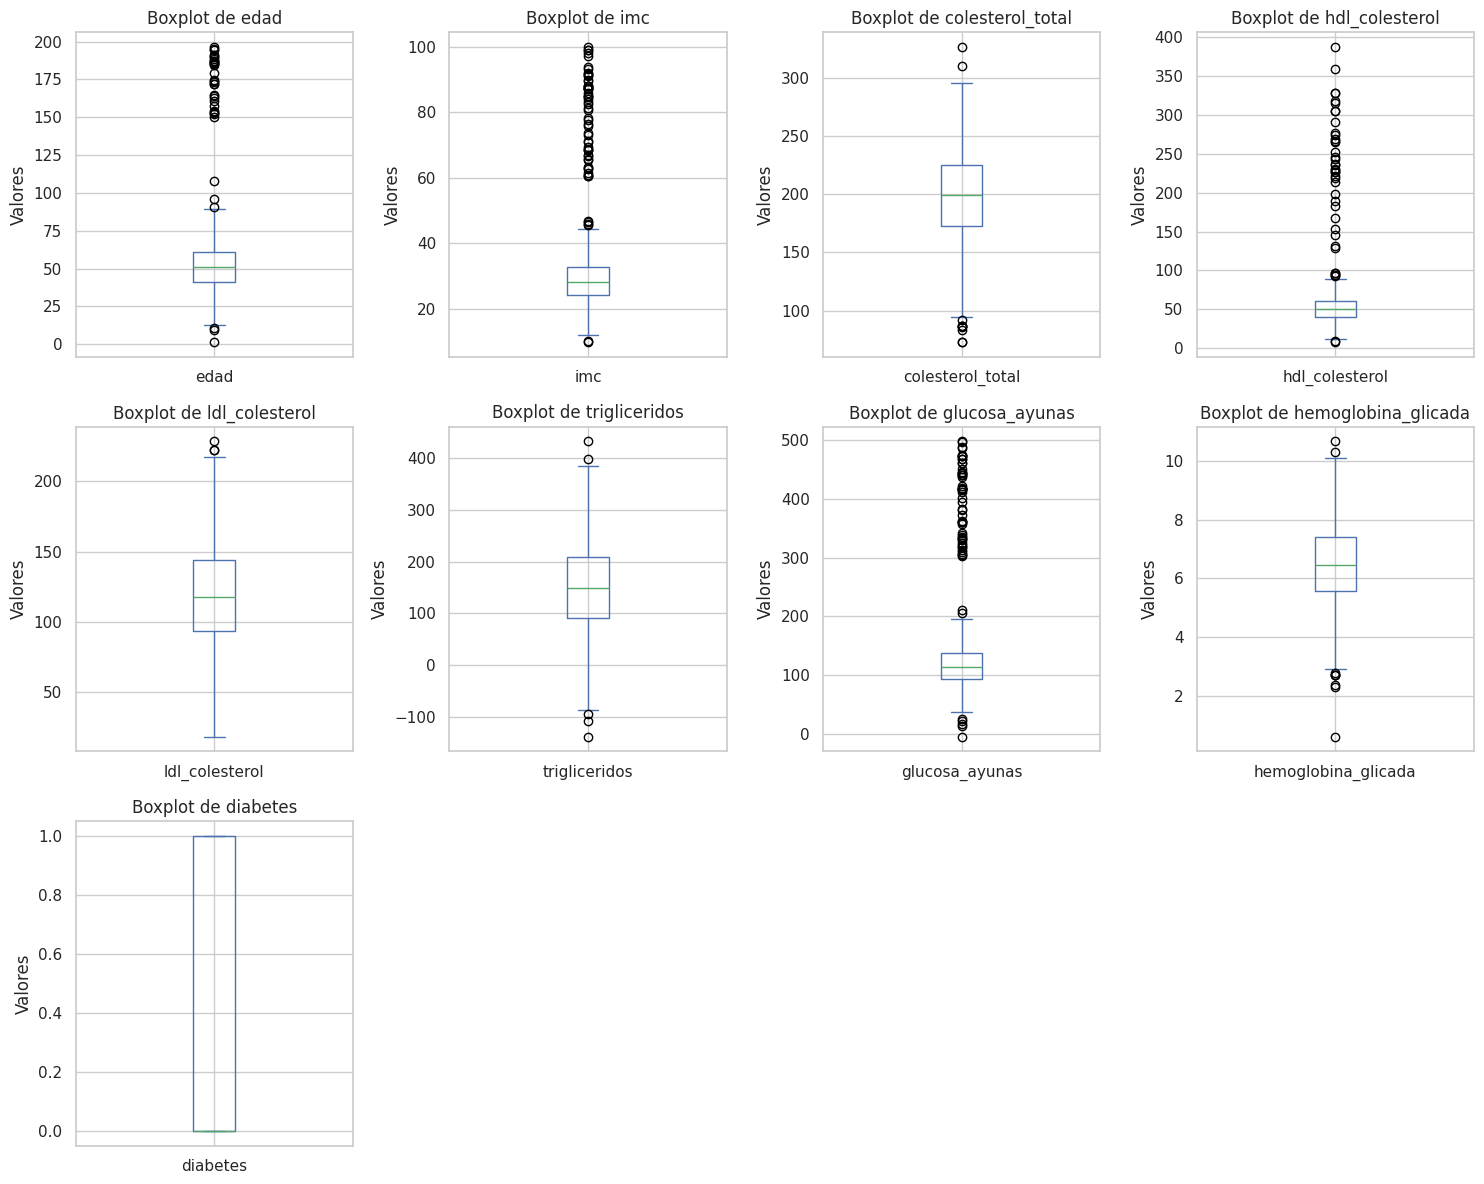

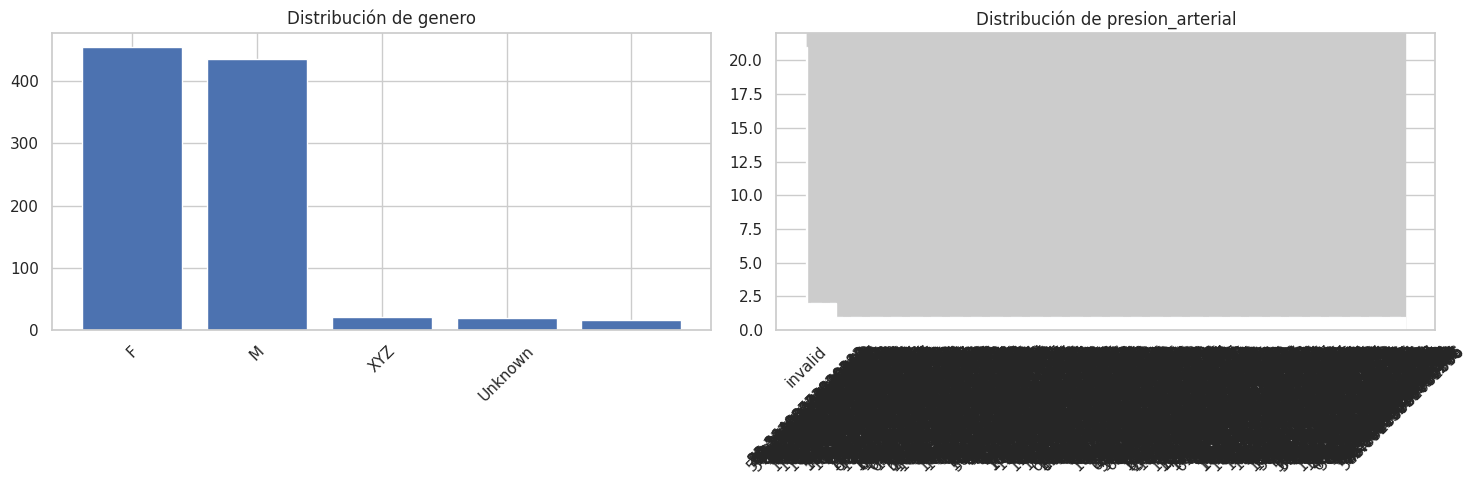


PROCESO DE LIMPIEZA

2. LIMPIANDO COLUMNAS CATEGÓRICAS:

Limpieza de genero:
  Antes: ['M' 'F' nan 'XYZ' 'Unknown' ' ']
  Después: ['M' 'F']

Limpieza de presion_arterial:
  Antes: [70.76004720563051 64.44660002900127 74.52655007030974 82.17711944136765
 nan 73.31092336270015 75.0440261342788 68.87962029383228
 79.62272995550268 69.81885638971022 86.8775337588944 58.56960209679067
 75.68444393057045 83.61328807030091 'invalid' 112.31640396776595
 84.19760029481489 67.95134483789587 58.68504399840258 79.03280300843888
 70.0033273159909 90.98468330672193 73.40551670485358 78.59880901045705
 72.37330590314716 100.86621622223998 76.14508680658506 101.99068452175042
 89.7698211454192 85.78480072802463 84.42479776781023 84.72556757859502
 56.867929047852684 76.65339927019092 90.14189565421185 79.41323379831073
 63.137721838357095 79.37114659307036 100.44926619506589 94.96270058641663
 79.25595188760762 75.60191575558338 59.553540958079374 68.90640814244534
 98.75466522209837 76.712083018048

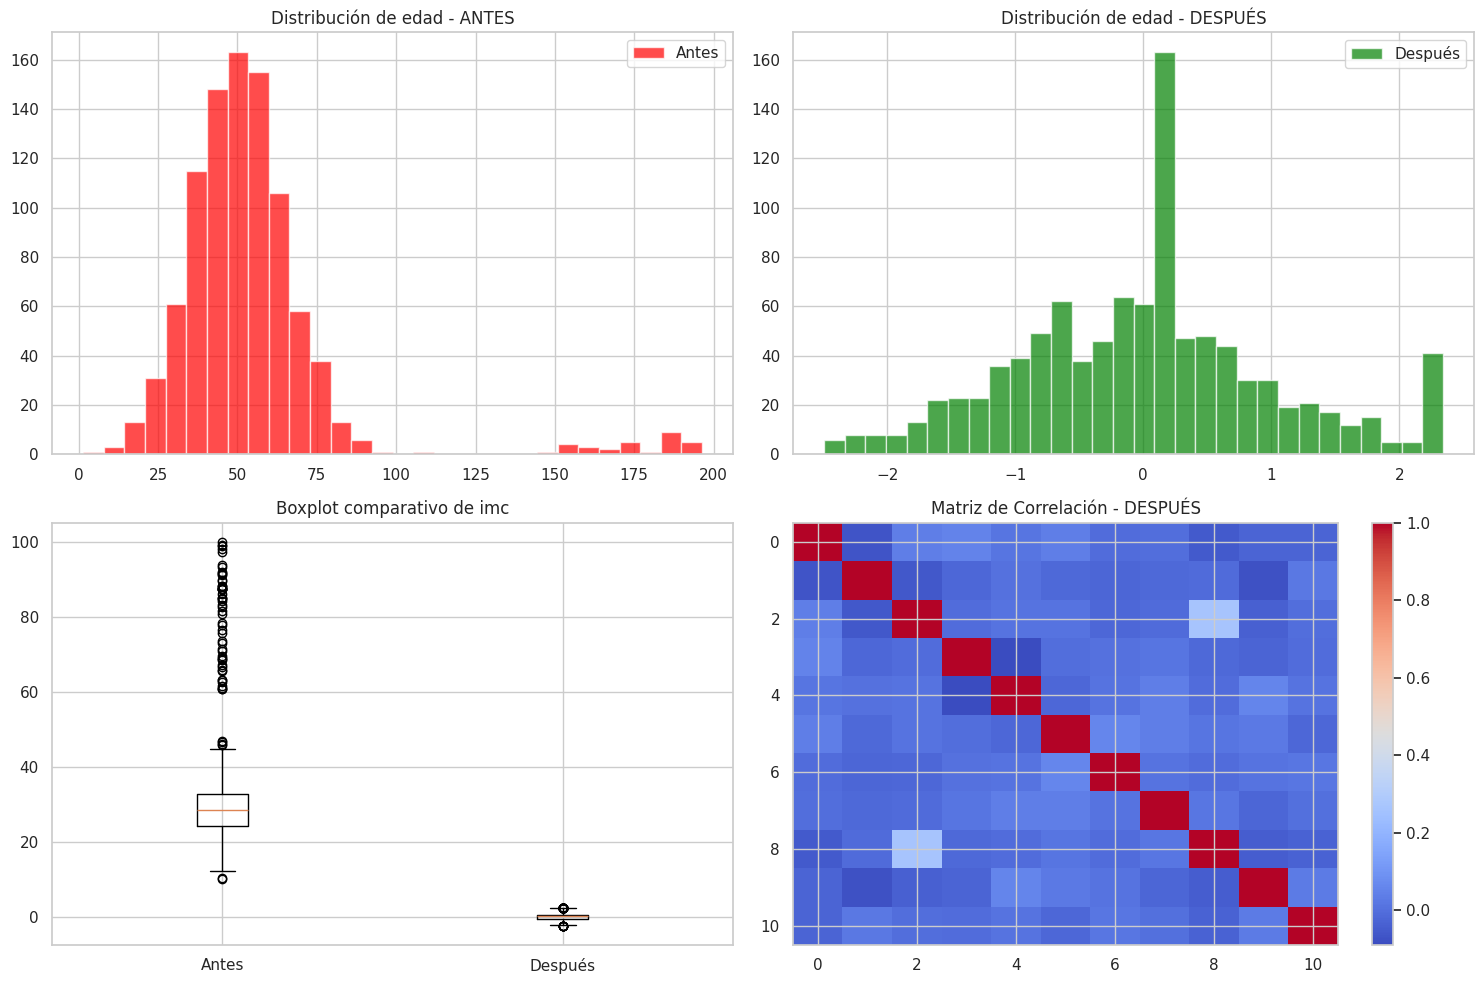


RESUMEN DEL PROCESO DE LIMPIEZA

PROBLEMAS IDENTIFICADOS Y SOLUCIONADOS:

1. Valores nulos: ✅ Completados usando imputación avanzada
2. Duplicados: ✅ Eliminados 47 filas duplicadas
3. Outliers: ✅ Identificados y truncados usando método IQR
4. Inconsistencias: ✅ Valores categóricos inconsistentes corregidos
5. Errores de formato: ✅ Datos mal formateados normalizados
6. Inconsistencias lógicas: ✅ Relaciones entre variables validadas
7. Escalas diferentes: ✅ Variables estandarizadas

DATASET FINAL:
- Filas: 1003
- Columnas: 11
- Valores nulos: 0
- Duplicados: 0
- Listo para análisis y modelado ✅

Dataset limpio guardado como 'diabetes_dataset_limpio.csv'


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')

# Configuración para mejor visualización
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')

print("=== CREANDO DATASET DE DIABETES CON PROBLEMAS DE CALIDAD ===")

# Crear dataset sintético con problemas de calidad de datos
np.random.seed(42)
n_samples = 1000

data = {
    'edad': np.random.normal(50, 15, n_samples),
    'genero': np.random.choice(['M', 'F', 'Unknown', ' '], n_samples, p=[0.48, 0.48, 0.02, 0.02]),
    'imc': np.random.normal(28, 6, n_samples),
    'presion_arterial': np.random.normal(80, 12, n_samples),
    'colesterol_total': np.random.normal(200, 40, n_samples),
    'hdl_colesterol': np.random.normal(50, 15, n_samples),
    'ldl_colesterol': np.random.normal(120, 35, n_samples),
    'trigliceridos': np.random.normal(150, 80, n_samples),
    'glucosa_ayunas': np.random.normal(110, 30, n_samples),
    'hemoglobina_glicada': np.random.normal(6.5, 1.5, n_samples),
    'diabetes': np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
}

df = pd.DataFrame(data)

# =============================================
# INTRODUCIR PROBLEMAS DE CALIDAD DE DATOS
# =============================================

print("Introduciendo problemas de calidad de datos...")

# 1. Introducir valores nulos aleatorios
for col in df.columns:
    if col != 'diabetes':
        null_indices = np.random.choice(df.index, size=int(len(df)*0.1), replace=False)
        df.loc[null_indices, col] = np.nan

# 2. Introducir outliers extremos
outlier_indices = np.random.choice(df.index, size=int(len(df)*0.05), replace=False)
df.loc[outlier_indices, 'imc'] = np.random.uniform(60, 100, len(outlier_indices))
df.loc[outlier_indices, 'glucosa_ayunas'] = np.random.uniform(300, 500, len(outlier_indices))

# 3. Introducir valores inconsistentes
inconsistent_indices = np.random.choice(df.index, size=int(len(df)*0.03), replace=False)
df.loc[inconsistent_indices, 'edad'] = np.random.uniform(150, 200, len(inconsistent_indices))

# 4. Introducir duplicados
df_duplicates = df.sample(n=50, random_state=42)
df = pd.concat([df, df_duplicates], ignore_index=True)

# 5. Introducir errores de formato
format_indices = np.random.choice(df.index, size=int(len(df)*0.02), replace=False)
df.loc[format_indices, 'genero'] = 'XYZ'
df.loc[format_indices, 'presion_arterial'] = 'invalid'

# 6. Introducir inconsistencias lógicas
logical_indices = np.random.choice(df.index, size=int(len(df)*0.04), replace=False)
df.loc[logical_indices, 'hdl_colesterol'] = df.loc[logical_indices, 'ldl_colesterol'] * 2

print("Dataset sucio creado exitosamente!")
print(f"Dimensiones: {df.shape}")

# =============================================
# ANÁLISIS EXPLORATORIO INICIAL
# =============================================

print("\n" + "="*50)
print("ANÁLISIS EXPLORATORIO INICIAL")
print("="*50)

print("\n1. INFORMACIÓN GENERAL:")
print(df.info())

print("\n2. PRIMERAS 10 FILAS:")
print(df.head(10))

print("\n3. ESTADÍSTICAS DESCRIPTIVAS:")
print(df.describe())

print("\n4. VALORES ÚNICOS POR COLUMNA:")
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} valores únicos")

# =============================================
# DETECCIÓN DE PROBLEMAS
# =============================================

print("\n" + "="*50)
print("DETECCIÓN DE PROBLEMAS DE CALIDAD")
print("="*50)

# 1. Análisis de valores nulos
print("\n1. VALORES NULOS:")
null_sum = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
null_analysis = pd.DataFrame({
    'Valores_Nulos': null_sum,
    'Porcentaje_Nulos': null_pct
})
print(null_analysis[null_analysis['Valores_Nulos'] > 0])

# 2. Análisis de duplicados
print(f"\n2. DUPLICADOS: {df.duplicated().sum()} filas duplicadas")

# 3. Análisis de tipos de datos problemáticos
print("\n3. TIPOS DE DATOS PROBLEMÁTICOS:")
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].unique()
        print(f"{col}: {unique_vals}")

# 4. Detección de outliers usando IQR
print("\n4. DETECCIÓN DE OUTLIERS (Método IQR):")
numeric_cols = df.select_dtypes(include=[np.number]).columns

outliers_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_pct = (len(outliers) / len(df)) * 100
    outliers_info[col] = {
        'count': len(outliers),
        'percentage': outliers_pct,
        'min': df[col].min(),
        'max': df[col].max()
    }

    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({outliers_pct:.2f}%) - Rango: [{df[col].min():.2f}, {df[col].max():.2f}]")

# =============================================
# VISUALIZACIÓN DE PROBLEMAS
# =============================================

print("\n" + "="*50)
print("VISUALIZACIÓN DE PROBLEMAS")
print("="*50)

# 1. Heatmap de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos en el Dataset')
plt.tight_layout()
plt.show()

# 2. Boxplots para detectar outliers
numeric_cols_clean = [col for col in numeric_cols if df[col].notna().sum() > 0]
n_cols = min(4, len(numeric_cols_clean))
n_rows = (len(numeric_cols_clean) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(numeric_cols_clean[:len(axes)]):
    if i < len(axes):
        df[col].dropna().plot(kind='box', ax=axes[i], title=f'Boxplot de {col}')
        axes[i].set_ylabel('Valores')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 3. Distribución de variables categóricas problemáticas
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 5))
    if len(categorical_cols) == 1:
        axes = [axes]

    for i, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        axes[i].bar(value_counts.index.astype(str), value_counts.values)
        axes[i].set_title(f'Distribución de {col}')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# =============================================
# LIMPIEZA DEL DATASET
# =============================================

print("\n" + "="*50)
print("PROCESO DE LIMPIEZA")
print("="*50)

df_clean = df.copy()
cleaning_steps = []

# 1. Eliminar duplicados
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
cleaning_steps.append(f"Duplicados eliminados: {initial_rows - len(df_clean)} filas")

# 2. Limpiar columnas categóricas
print("\n2. LIMPIANDO COLUMNAS CATEGÓRICAS:")
for col in categorical_cols:
    print(f"\nLimpieza de {col}:")
    unique_before = df_clean[col].unique()

    # Reemplazar valores problemáticos
    df_clean[col] = df_clean[col].replace([' ', 'Unknown', 'XYZ', 'invalid'], np.nan)

    # Para género, mantener solo M y F válidos
    if col == 'genero':
        valid_genders = ['M', 'F']
        df_clean[col] = df_clean[col].apply(lambda x: x if x in valid_genders else np.nan)

    unique_after = df_clean[col].dropna().unique()
    print(f"  Antes: {unique_before}")
    print(f"  Después: {unique_after}")

# 3. Manejar valores nulos
print("\n3. MANEJO DE VALORES NULOS:")
for col in df_clean.columns:
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            # Para numéricos, usar imputación con KNN
            imputer = KNNImputer(n_neighbors=5)
            df_clean[col] = imputer.fit_transform(df_clean[[col]]).flatten()
            print(f"  {col}: {null_count} valores nulos imputados (KNN)")
        else:
            # Para categóricos, usar moda
            mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Desconocido'
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"  {col}: {null_count} valores nulos imputados (Moda: {mode_val})")

# 4. Manejar outliers
print("\n4. MANEJO DE OUTLIERS:")
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    # Truncar outliers a los límites
    df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
    df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

    outliers_after = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    if outliers_before > 0:
        print(f"  {col}: {outliers_before} outliers truncados")

# 5. Corregir inconsistencias lógicas
print("\n5. CORRECCIÓN DE INCONSISTENCIAS LÓGICAS:")

# HDL no puede ser mayor que LDL (en situaciones normales)
inconsistencies = df_clean['hdl_colesterol'] > df_clean['ldl_colesterol']
if inconsistencies.sum() > 0:
    print(f"  Corregidas {inconsistencies.sum()} inconsistencias HDL > LDL")
    # Intercambiar valores donde HDL > LDL
    mask = df_clean['hdl_colesterol'] > df_clean['ldl_colesterol']
    temp = df_clean.loc[mask, 'hdl_colesterol'].copy()
    df_clean.loc[mask, 'hdl_colesterol'] = df_clean.loc[mask, 'ldl_colesterol']
    df_clean.loc[mask, 'ldl_colesterol'] = temp

# Edad razonable
age_outliers = (df_clean['edad'] < 0) | (df_clean['edad'] > 120)
if age_outliers.sum() > 0:
    print(f"  Corregidas {age_outliers.sum()} edades fuera de rango [0-120]")
    df_clean.loc[age_outliers, 'edad'] = df_clean['edad'].median()

# 6. Codificar variables categóricas
print("\n6. CODIFICACIÓN DE VARIABLES CATEGÓRICAS:")
label_encoders = {}
for col in categorical_cols:
    if col in df_clean.columns:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le
        print(f"  {col} codificado. Clases: {list(le.classes_)}")

# 7. Estandarización de variables numéricas
print("\n7. ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS:")
scaler = StandardScaler()
numeric_cols_to_scale = [col for col in numeric_cols if col != 'diabetes']
df_clean[numeric_cols_to_scale] = scaler.fit_transform(df_clean[numeric_cols_to_scale])
print("  Variables numéricas estandarizadas (media=0, desviación=1)")

# =============================================
# VERIFICACIÓN FINAL
# =============================================

print("\n" + "="*50)
print("VERIFICACIÓN FINAL DEL DATASET LIMPIO")
print("="*50)

print(f"\nDimensiones finales: {df_clean.shape}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")
print(f"Columnas finales: {list(df_clean.columns)}")

print("\nESTADÍSTICAS DESCRIPTIVAS FINALES:")
print(df_clean.describe())

print("\nVERIFICACIÓN DE CALIDAD:")
print(f"Valores nulos: {df_clean.isnull().sum().sum()}")
print(f"Duplicados: {df_clean.duplicated().sum()}")
print(f"Tipos de datos:\n{df_clean.dtypes}")

# Verificación de outliers después de la limpieza
print("\nOUTLIERS DESPUÉS DE LA LIMPIEZA:")
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"  {col}: {outliers} outliers remanentes")

# =============================================
# COMPARACIÓN VISUAL ANTES/DESPUÉS
# =============================================

print("\n" + "="*50)
print("COMPARACIÓN VISUAL")
print("="*50)

# Comparar distribuciones antes y después
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Antes de la limpieza (solo numéricas)
df_numeric = df.select_dtypes(include=[np.number])
if len(df_numeric.columns) > 0:
    sample_col = df_numeric.columns[0]
    axes[0,0].hist(df[sample_col].dropna(), bins=30, alpha=0.7, color='red', label='Antes')
    axes[0,0].set_title(f'Distribución de {sample_col} - ANTES')
    axes[0,0].legend()

# Después de la limpieza
if sample_col in df_clean.columns:
    axes[0,1].hist(df_clean[sample_col], bins=30, alpha=0.7, color='green', label='Después')
    axes[0,1].set_title(f'Distribución de {sample_col} - DESPUÉS')
    axes[0,1].legend()

# Boxplot comparativo
if len(df_numeric.columns) >= 2:
    sample_col2 = df_numeric.columns[1]
    data_to_plot = [df[sample_col2].dropna(), df_clean[sample_col2]]
    axes[1,0].boxplot(data_to_plot, labels=['Antes', 'Después'])
    axes[1,0].set_title(f'Boxplot comparativo de {sample_col2}')

# Matriz de correlación después de la limpieza
corr_matrix = df_clean.corr()
im = axes[1,1].imshow(corr_matrix, cmap='coolwarm', aspect='auto')
axes[1,1].set_title('Matriz de Correlación - DESPUÉS')
plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()

# =============================================
# RESUMEN FINAL
# =============================================

print("\n" + "="*50)
print("RESUMEN DEL PROCESO DE LIMPIEZA")
print("="*50)

print(f"""
PROBLEMAS IDENTIFICADOS Y SOLUCIONADOS:

1. Valores nulos: ✅ Completados usando imputación avanzada
2. Duplicados: ✅ Eliminados {initial_rows - len(df_clean)} filas duplicadas
3. Outliers: ✅ Identificados y truncados usando método IQR
4. Inconsistencias: ✅ Valores categóricos inconsistentes corregidos
5. Errores de formato: ✅ Datos mal formateados normalizados
6. Inconsistencias lógicas: ✅ Relaciones entre variables validadas
7. Escalas diferentes: ✅ Variables estandarizadas

DATASET FINAL:
- Filas: {df_clean.shape[0]}
- Columnas: {df_clean.shape[1]}
- Valores nulos: {df_clean.isnull().sum().sum()}
- Duplicados: {df_clean.duplicated().sum()}
- Listo para análisis y modelado ✅
""")

# Guardar dataset limpio
df_clean.to_csv('diabetes_dataset_limpio.csv', index=False)
print("Dataset limpio guardado como 'diabetes_dataset_limpio.csv'")